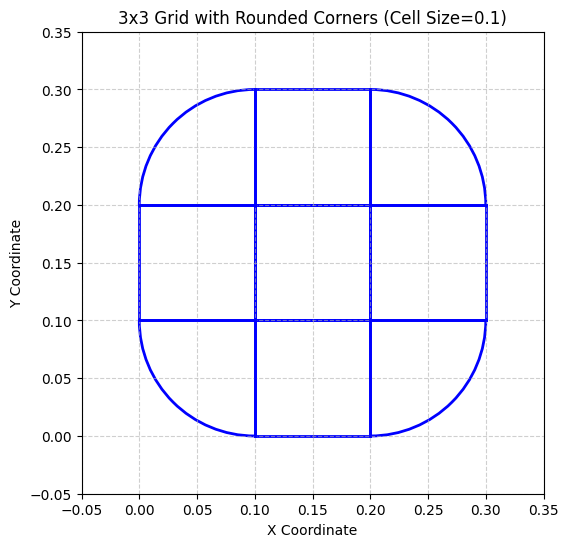

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_geometric_grid():
    """
    Draws a 3x3 grid where the outer corners are rounded
    with a radius of 0.1, and inner cells are square.
    """
    
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_aspect('equal')
    
    cell_size = 0.1
    radius = 0.1
    color = 'blue'
    lw = 2  # Line width
    
    # Loop through a 3x3 grid
    # (i, j) represents (row, col) from the top-left (0, 0)
    for i in range(3):
        for j in range(3):
            # Calculate the bottom-left (x, y) coordinate for matplotlib
            # We map row 0 to y=0.2, row 1 to y=0.1, row 2 to y=0.0
            x = j * cell_size
            y = (2 - i) * cell_size
            
            # Check for the four corner cells
            if (i, j) == (0, 0):  # Top-left cell
                # Inner corner (center of arc) is at (0.1, 0.2)
                arc_center = (x + radius, y)
                # Draw inner lines
                ax.plot([x, x + radius], [y, y], color=color, lw=lw)  # Bottom line
                ax.plot([x + radius, x + radius], [y, y + radius], color=color, lw=lw)  # Right line
                # Draw outer arc
                arc = patches.Arc(arc_center, 2 * radius, 2 * radius, angle=0,
                                  theta1=90, theta2=180, color=color, lw=lw)
                ax.add_patch(arc)
                
            elif (i, j) == (0, 2):  # Top-right cell
                # Inner corner (center of arc) is at (0.2, 0.2)
                arc_center = (x, y)
                # Draw inner lines
                ax.plot([x, x + radius], [y, y], color=color, lw=lw)  # Bottom line
                ax.plot([x, x], [y, y + radius], color=color, lw=lw)  # Left line
                # Draw outer arc
                arc = patches.Arc(arc_center, 2 * radius, 2 * radius, angle=0,
                                  theta1=0, theta2=90, color=color, lw=lw)
                ax.add_patch(arc)
                
            elif (i, j) == (2, 0):  # Bottom-left cell
                # Inner corner (center of arc) is at (0.1, 0.1)
                arc_center = (x + radius, y + radius)
                # Draw inner lines
                ax.plot([x, x + radius], [y + radius, y + radius], color=color, lw=lw)  # Top line
                ax.plot([x + radius, x + radius], [y, y + radius], color=color, lw=lw)  # Right line
                # Draw outer arc
                arc = patches.Arc(arc_center, 2 * radius, 2 * radius, angle=0,
                                  theta1=180, theta2=270, color=color, lw=lw)
                ax.add_patch(arc)
                
            elif (i, j) == (2, 2):  # Bottom-right cell
                # Inner corner (center of arc) is at (0.2, 0.1)
                arc_center = (x, y + radius)
                # Draw inner lines
                ax.plot([x, x + radius], [y + radius, y + radius], color=color, lw=lw)  # Top line
                ax.plot([x, x], [y, y + radius], color=color, lw=lw)  # Left line
                # Draw outer arc
                arc = patches.Arc(arc_center, 2 * radius, 2 * radius, angle=0,
                                  theta1=270, theta2=360, color=color, lw=lw)
                ax.add_patch(arc)
                
            else:
                # This is one of the 5 inner/middle cells
                # Draw a simple square
                rect = patches.Rectangle((x, y), cell_size, cell_size,
                                         fill=False, edgecolor=color, lw=lw)
                ax.add_patch(rect)

    # Set plot limits and labels
    ax.set_xlim(-0.05, 0.35)
    ax.set_ylim(-0.05, 0.35)
    ax.set_title("3x3 Grid with Rounded Corners (Cell Size=0.1)")
    ax.set_xlabel("X Coordinate")
    ax.set_ylabel("Y Coordinate")
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Show the plot
    plt.show()

if __name__ == "__main__":
    draw_geometric_grid()

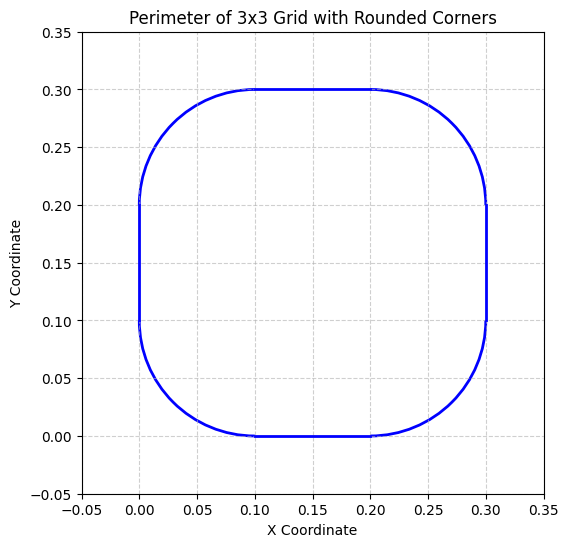

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_rounded_perimeter():
    """
    Draws the outer perimeter of a 3x3 grid (0.3x0.3 total size)
    with its corners rounded by a radius of 0.1.
    All internal grid lines are removed.
    """
    
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_aspect('equal')
    
    radius = 0.1
    color = 'blue'
    lw = 2  # Line width
    
    # --- Define the 8 components of the perimeter ---
    
    # 1. Four quarter-circle arcs at the corners
    # Arc(center, width, height, angle=0, theta1, theta2)
    # Note: width and height are 2 * radius
    
    # Top-Left Arc
    # Center (0.1, 0.2), connects (0.0, 0.2) to (0.1, 0.3)
    arc_tl = patches.Arc((0.1, 0.2), 2 * radius, 2 * radius, angle=0,
                         theta1=90, theta2=180, color=color, lw=lw)
    
    # Top-Right Arc
    # Center (0.2, 0.2), connects (0.2, 0.3) to (0.3, 0.2)
    arc_tr = patches.Arc((0.2, 0.2), 2 * radius, 2 * radius, angle=0,
                         theta1=0, theta2=90, color=color, lw=lw)
    
    # Bottom-Left Arc
    # Center (0.1, 0.1), connects (0.1, 0.0) to (0.0, 0.1)
    arc_bl = patches.Arc((0.1, 0.1), 2 * radius, 2 * radius, angle=0,
                         theta1=180, theta2=270, color=color, lw=lw)
    
    # Bottom-Right Arc
    # Center (0.2, 0.1), connects (0.3, 0.1) to (0.2, 0.0)
    arc_br = patches.Arc((0.2, 0.1), 2 * radius, 2 * radius, angle=0,
                         theta1=270, theta2=360, color=color, lw=lw)
    
    ax.add_patch(arc_tl)
    ax.add_patch(arc_tr)
    ax.add_patch(arc_bl)
    ax.add_patch(arc_br)
    
    # 2. Four straight lines connecting the arcs
    
    # Top line: connects arc_tl (0.1, 0.3) to arc_tr (0.2, 0.3)
    ax.plot([0.1, 0.2], [0.3, 0.3], color=color, lw=lw)
    
    # Bottom line: connects arc_bl (0.1, 0.0) to arc_br (0.2, 0.0)
    ax.plot([0.1, 0.2], [0.0, 0.0], color=color, lw=lw)
    
    # Left line: connects arc_bl (0.0, 0.1) to arc_tl (0.0, 0.2)
    ax.plot([0.0, 0.0], [0.1, 0.2], color=color, lw=lw)
    
    # Right line: connects arc_br (0.3, 0.1) to arc_tr (0.3, 0.2)
    ax.plot([0.3, 0.3], [0.1, 0.2], color=color, lw=lw)

    # --- Set plot limits and labels ---
    ax.set_xlim(-0.05, 0.35)
    ax.set_ylim(-0.05, 0.35)
    ax.set_title("Perimeter of 3x3 Grid with Rounded Corners")
    ax.set_xlabel("X Coordinate")
    ax.set_ylabel("Y Coordinate")
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Show the plot
    plt.show()

if __name__ == "__main__":
    draw_rounded_perimeter()

In [1]:
import pybullet as p
import pybullet_data
import time
import math

def draw_arc_pybullet(center, radius, start_angle_rad, end_angle_rad, color,
                      line_width=2, lifetime=0, num_segments=20):
    """
    Draws an arc in PyBullet using a series of short debug lines.
    Returns a list of the debug line IDs.
    """
    arc_ids = []
    prev_pt = None
    
    for i in range(num_segments + 1):
        angle = start_angle_rad + (end_angle_rad - start_angle_rad) * i / num_segments
        
        # Calculate point on circle
        x = center[0] + radius * math.cos(angle)
        y = center[1] + radius * math.sin(angle)
        z = center[2]
        current_pt = [x, y, z]

        if prev_pt is not None:
            # Add the line and store its ID
            line_id = p.addUserDebugLine(prev_pt, current_pt, lineColorRGB=color,
                                         lineWidth=line_width, lifeTime=lifetime)
            arc_ids.append(line_id)
        
        prev_pt = current_pt
        
    return arc_ids

def draw_rounded_perimeter_pybullet(center_pos, color=[0, 0, 1],
                                    line_width=3, lifetime=0):
    """
    Draws the 0.3x0.3 rounded perimeter shape in PyBullet.
    Returns a list of all debug item IDs created for this shape.
    """
    
    all_ids = []
    cx, cy, z = center_pos
    
    # --- Re-centering the coordinates ---
    # Shape is 0.3x0.3. Center is (0.15, 0.15) in its local frame.
    # We map this to (cx, cy)
    r_center = 0.05 # Arc center offset from main center
    r_edge = 0.15  # Straight edge offset from main center
    
    # 1. Draw the 4 straight lines and store their IDs
    
    # Top line
    line_id = p.addUserDebugLine([cx - r_center, cy + r_edge, z], [cx + r_center, cy + r_edge, z],
                                 lineColorRGB=color, lineWidth=line_width, lifeTime=lifetime)
    all_ids.append(line_id)
    
    # Bottom line
    line_id = p.addUserDebugLine([cx - r_center, cy - r_edge, z], [cx + r_center, cy - r_edge, z],
                                 lineColorRGB=color, lineWidth=line_width, lifeTime=lifetime)
    all_ids.append(line_id)
    
    # Left line
    line_id = p.addUserDebugLine([cx - r_edge, cy - r_center, z], [cx - r_edge, cy + r_center, z],
                                 lineColorRGB=color, lineWidth=line_width, lifeTime=lifetime)
    all_ids.append(line_id)
    
    # Right line
    line_id = p.addUserDebugLine([cx + r_edge, cy - r_center, z], [cx + r_edge, cy + r_center, z],
                                 lineColorRGB=color, lineWidth=line_width, lifeTime=lifetime)
    all_ids.append(line_id)

    # 2. Draw the 4 0.1-radius arcs and store their IDs
    
    # Arc centers
    tr_center = [cx + r_center, cy + r_center, z]
    tl_center = [cx - r_center, cy + r_center, z]
    bl_center = [cx - r_center, cy - r_center, z]
    br_center = [cx + r_center, cy - r_center, z]
    
    # Top-Right Arc
    arc_ids = draw_arc_pybullet(tr_center, 0.1, 0, math.pi / 2, color, line_width, lifetime)
    all_ids.extend(arc_ids) # Use extend to add all items from the list
    
    # Top-Left Arc
    arc_ids = draw_arc_pybullet(tl_center, 0.1, math.pi / 2, math.pi, color, line_width, lifetime)
    all_ids.extend(arc_ids)
    
    # Bottom-Left Arc
    arc_ids = draw_arc_pybullet(bl_center, 0.1, math.pi, 3 * math.pi / 2, color, line_width, lifetime)
    all_ids.extend(arc_ids)
    
    # Bottom-Right Arc
    arc_ids = draw_arc_pybullet(br_center, 0.1, 3 * math.pi / 2, 2 * math.pi, color, line_width, lifetime)
    all_ids.extend(arc_ids)
    
    # Return the master list of all IDs
    return all_ids

def remove_debug_shape(shape_ids):
    """
    Removes a debug shape from PyBullet given its list of item IDs.
    """
    for item_id in shape_ids:
        p.removeUserDebugItem(item_id)
    print(f"Removed {len(shape_ids)} debug items.")

pybullet build time: Feb 15 2025 12:06:37


In [2]:
physicsClient = p.connect(p.GUI)
p.setGravity(0, 0, 0)

p.resetDebugVisualizerCamera(cameraDistance=1.0, cameraYaw=45, cameraPitch=-30,
                                cameraTargetPosition=[0.25, 0, 0])

# --- Demonstration of the interactive workflow ---

# 1. Draw two shapes and store their IDs
print("Drawing two shapes (red and green)...")
red_shape_ids = draw_rounded_perimeter_pybullet(center_pos=[0, 0, 0.1],
                                                color=[1, 0, 0], lifetime=0)

Version = 4.1 Metal - 89.4
Vendor = Apple
Renderer = Apple M1
Drawing two shapes (red and green)...
b3Printf: Selected demo: Physics Server
startThreads creating 1 threads.
starting thread 0
started thread 0 
MotionThreadFunc thread started


In [3]:
while True:
    p.stepSimulation()
    time.sleep(1.0/240.0)

KeyboardInterrupt: 

In [4]:
remove_debug_shape(red_shape_ids)

Removed 84 debug items.


In [2]:
import numpy as np
np.cos(np.pi/2)

6.123233995736766e-17